# Assusmptions of Linear Regression

Linear regression works reliably only when certain key assumptions about the data are met. These assumptions ensure that the model's estimates are accurate, unbiased, and suitable for prediction. Understanding and checking them is essential for building a valid regression model

---

> ## Assumptions:
>

### Linearity

The relationship between the predictors $X$ and the expected value $Y$ is linear in the parameters

$$E(Y|X) = \beta_0 + \beta_1X_1 + \dots + \beta_pX_p$$

**What it means**:
If you change **$X_1$** by 1 unit, the expected change in $Y$ is $\beta_1$ $-$ **constant**, regardless of the vaue of $X_1$

**Why it matters**:
If the true relationship is curved (e.g., quadratic, exponential), a straight line will **systematically miss** the pattern. Your residual will show a pattern (not random)

**How to check**:
- Scatter plots of $Y$ vs each $X$
- Residuals vs Fitted values plot - should show no pattern (random cloud around 0)
- Added variable plots (partial regression plots)

**What to do if violated**:
- Add polynomial terms $(X^2, X^3)$
- Transform variables (log, square root)
- Use splines or non-linear models

---

### Independence of Errors

The errors $\epsilon_i$ are **independent*** of each other
$$Cov(\epsilon_i, \epsilon_j) = 0 \quad for \quad i \ne j$$

**What it means**:
One observation's error gives you **no  information** about another obesrvation's error

**Why it matters**:
If errors are correlated (e.g., time series data, clustered data), your standard errors are **underestimated &rarr;** you get **too many false positives** (Type I error inflation)

**How to check**:
- Durbin-Watson test (for autocorrelation)
- Residuals vs order/time plot
- ACF/PACF for residuals

**What to do if violated**:
- Use time series models (ARIMA, etc.)
- Use clustered standard errors
- Use mixed-effects models

---
### Normality of Errors

The errors $\epsilon$ are **normally distributed** with mean 0:
$$\epsilon \sim N(0, \sigma_2)$$

**Important clarification**:
This is about **errors**, not the variables themselves. $X$'s and $Y$ do not need to be normal. the **residuals** should look normal

**Why it matters**:
Normality is needed for
- **Exact** $t-tests$ and $F-tests$ in small samples
- Valid confidence intervals

In **large samples**, the Central Limit Theorem kicks in, and OLS coefficients are approximately normal anyway $-$ so this assumption matters most for **small samples**

**How to check**:
- Q-Q plot of residuals
- Histogram of residuals
- Shapiro-Wilk test, Kolmogorov-Smirnov test

**What to do if violated**:
- Transform $Y$ (log, Box-Cox)
- Remove extreme outliers (carefully)
- Use robust regression
- Bootstrap standard errors

---

### Homoscedasticity (Equal Variance)

The variance of the errors is **constant** across all levels of $X$:
$$Var(\epsilon_i) = \sigma^2 \quad \text{for all } i$$

**What it means**:
The spread of residuals should be roughly the same whether $X$ is samll or large

**Why it matters**:
If variance changes (heteroscedasticity)
- OLS estimates are still unbiased
- But standard errors are **wrong**
- t-tests and F-tests become unreliable
- Efficiency is lost (weighted least squares would be better)

**How to check**:
- Residuals vs Fitted plot $-$ look for funnel shape, or increasing/decreasing spread
- Breusch-Pagan test
- White test
- Scale-Location plot

**What to do if violated**:
- Transform $Y$ (log often helps)
- Use weighted least squares
- Use heteroscedasticity-robust standard errors (White, HC3)
- Use bootstrap

---

### No Perfect Multicollinearity
No preictor is a **perfect linear combination** of others

**What it means**:
You cannot have $X_3 = 2X_1 + 5X_2$ exactly. If you do, the matrix $X^TX$ becomes **singular** and cannot be inverted &rarr; OLS has no unique solution

**Why it matters**:
- **Perfect multicollinearity** &rarr; model cannot be estimated
- **High (but not prefect) mulitcollinearity** &rarr; become coefficients become unstable, standard errors inflate, signs may flip

**How to check**:
- Correlation matrix
- Variance Inflation Factor (VIF) $-$ VIF > 5 or 10 is concernig
- Condition number of $X^TX$

**What to do if violated**:
- Remove one of the correlated variables
- Combine them (PCA, average)
- Use regularization (Ridge, Lasso)
- Collect more data


<div style = 'background-color: #abcdaf'>      When two variables move together, the model cannot tell which one is actually causing the effect on Y. For this reason multicollinearity is bad.</div>

---

### No Influential Outliers 
No single observation should **disproportionately** influence the model fit

**Why it matters**:
A single outlier can:
- Pull the regression line toward itself
- Change coefficients dramatically
- Inflate or deflate standard errors

**How to check**:
- Cook's Distance
- Leverage (hat values)
- Studentized residuals
- DFBETA

**What to do if violated**:
- Investigate the outlier $-$ is it data entry error?
- Consider robust regression
- Report results with and without the outlier

---


# Checking Linear Regression Assumptions Through Code

### Step 0: Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

> We use **statsmodels** (not sklearn) because it gives us full statistical diagnostics $-$ p-values, residual tests, influence measures

#### Step 1: Load a Dataset

In [2]:
df = sns.load_dataset('mpg').dropna()
df = df[['mpg', 'horsepower', 'weight', 'displacement']]
df.head()

,mpg,horsepower,weight,displacement
0,18.0,130.0,3504,307.0
1,15.0,165.0,3693,350.0
2,18.0,150.0,3436,318.0
3,16.0,150.0,3433,304.0
4,17.0,140.0,3449,302.0


In [3]:
df.shape

(392, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   horsepower    392 non-null    float64
 2   weight        392 non-null    int64  
 3   displacement  392 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 15.3 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.445918,7.805007,9.0,17.00,22.75,29.00,46.6
horsepower,392.0,104.469388,38.491160,46.0,75.00,93.50,126.00,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.25,2803.50,3614.75,5140.0
displacement,392.0,194.411990,104.644004,68.0,105.00,151.00,275.75,455.0


In [17]:
df.tail()

,mpg,horsepower,weight,displacement
393,27.0,86.0,2790,140.0
394,44.0,52.0,2130,97.0
395,32.0,84.0,2295,135.0
396,28.0,79.0,2625,120.0
397,31.0,82.0,2720,119.0


> We will predict **mpg** from **horsepower, weight,** and **displacement**

In [19]:
X = df[['horsepower', 'weight', 'displacement']]
y = df['mpg']
X.head()

,horsepower,weight,displacement
0,130.0,3504,307.0
1,165.0,3693,350.0
2,150.0,3436,318.0
3,150.0,3433,304.0
4,140.0,3449,302.0


In [25]:
# Add constatn (intercept term) - critical in statesmodels
X = sm.add_constant(X)
X.head()

,const,horsepower,weight,displacement
0,1.0,130.0,3504,307.0
1,1.0,165.0,3693,350.0
2,1.0,150.0,3436,318.0
3,1.0,150.0,3433,304.0
4,1.0,140.0,3449,302.0


In [27]:
# Fit OLS
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     312.0
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          5.10e-103
Time:                        09:11:22   Log-Likelihood:                -1120.6
No. Observations:                 392   AIC:                             2249.
Df Residuals:                     388   BIC:                             2265.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           44.8559      1.196     37.507      0.000      42.505      47.207
horsepower      -0.0417      0.013     -3.252      0.001      -0.067      -0.016
weight          -0.0054      0.001     -7.513      0.000      -0.007      -0.004
displacement    -0.0058      0.007     -0.876      0.381      -0.019       0.007
==============================================================================
Omnibus:                       37.603   Durbin-Watson:                   0.859
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.946
Skew:                           0.707   Prob(JB):                     1.43e-11
Kurtosis:                       4.029   Cond. No.                     1.73e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.73e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Step 2: Linearity

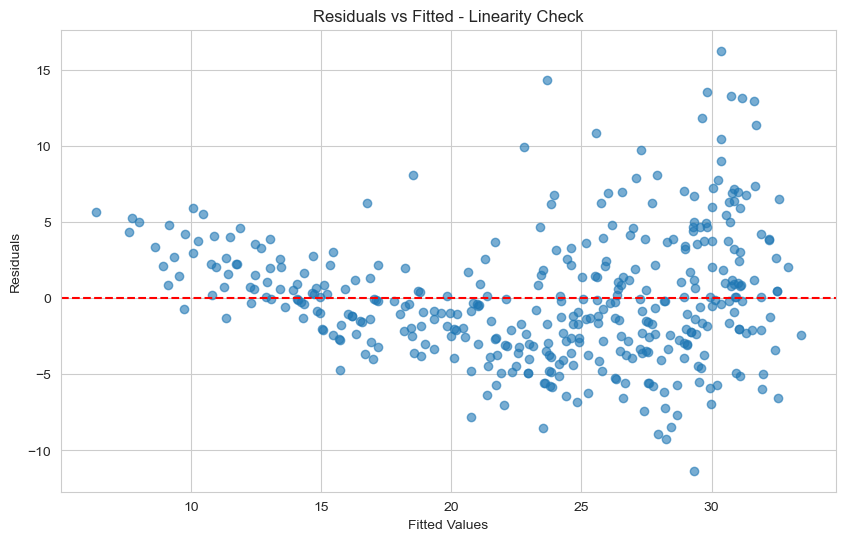

In [28]:
fitted = model.fittedvalues
residuals = model.resid

plt.scatter(fitted, residuals, alpha = 0.6)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted - Linearity Check')

plt.show()

> From the above graph it is clearly visible that the shape formed by the blue dots relative to the horizontal red dashed line (where residual = 0) is kind of U-shape or like a Curve.
>
> The variance (spread) is not same as move from left to right.

#### Visual Check - Partial Rergression Plots

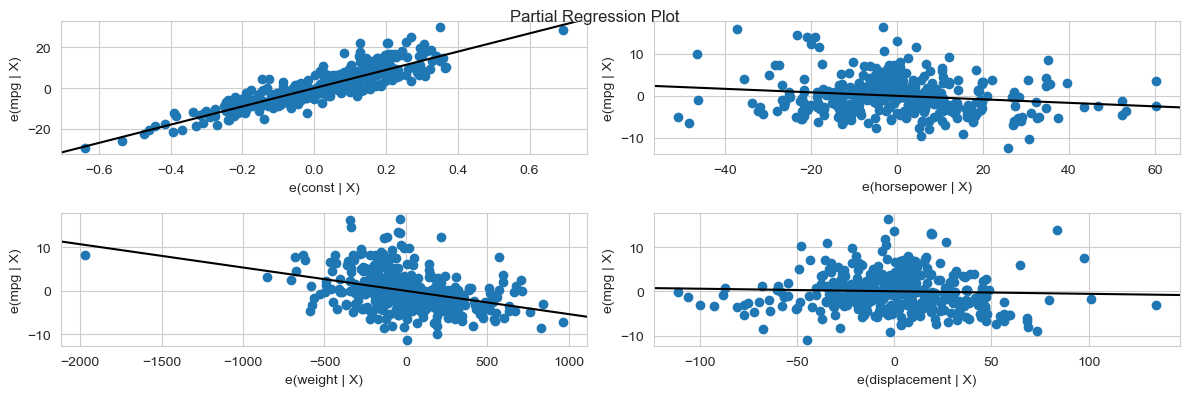

In [29]:
fig = plt.figure(figsize = (12, 4))
sm.graphics.plot_partregress_grid(model, fig = fig)

plt.show()

In [32]:
# Formal test - Ranibow Test
from statsmodels.stats.diagnostic import linear_rainbow
test_stat, p_value = linear_rainbow(model)
print(f'Rainbow test: stat = {test_stat:.3f}, p = {p_value:.3f}')

Rainbow test: stat = 2.792, p = 0.000


#### Fix if Violated

In [33]:
# Add polynomial term
df['horsepower_sq'] = df['horsepower']**2
X2 = sm.add_constant(df[['horsepower','horsepower_sq', 'weight','displacement']])
X2.head()

,const,horsepower,horsepower_sq,weight,displacement
0,1.0,130.0,16900.0,3504,307.0
1,1.0,165.0,27225.0,3693,350.0
2,1.0,150.0,22500.0,3436,318.0
3,1.0,150.0,22500.0,3433,304.0
4,1.0,140.0,19600.0,3449,302.0


In [36]:
model2 = sm.OLS(y, X2).fit()

# Or log-transform
df['log_mpg'] = np.log(df['mpg'])

In [37]:
df.head()

,mpg,horsepower,weight,displacement,horsepower_sq,log_mpg
0,18.0,130.0,3504,307.0,16900.0,2.890372
1,15.0,165.0,3693,350.0,27225.0,2.708050
2,18.0,150.0,3436,318.0,22500.0,2.890372
3,16.0,150.0,3433,304.0,22500.0,2.772589
4,17.0,140.0,3449,302.0,19600.0,2.833213


#### Step 3: Independence of Errors

In [38]:
dw = durbin_watson(model.resid)
print(f'Durbin-Watson: {dw}')

Durbin-Watson: 0.8587513374458708


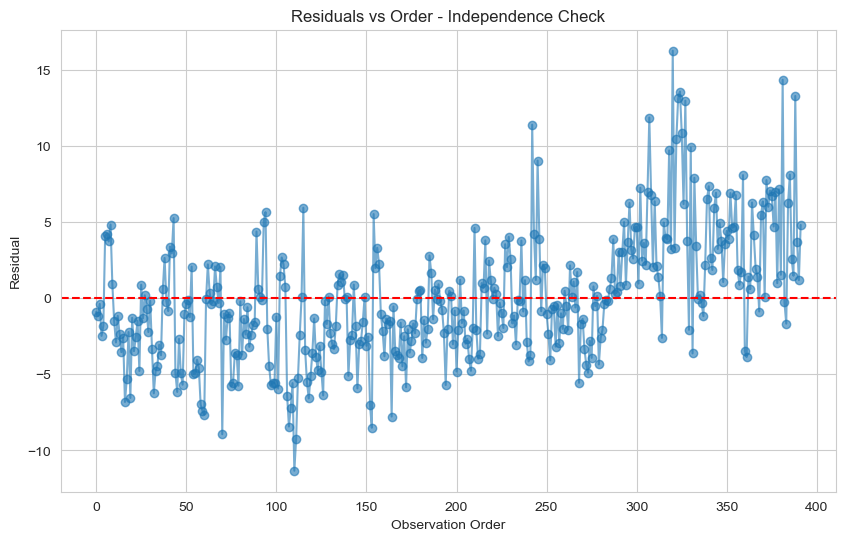

In [41]:
# Visual - Residuals vs Order
plt.plot(model.resid.values, marker = 'o', linestyle = '-', alpha = 0.6)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Observation Order')
plt.ylabel('Residual')
plt.title('Residuals vs Order - Independence Check')
plt.show()

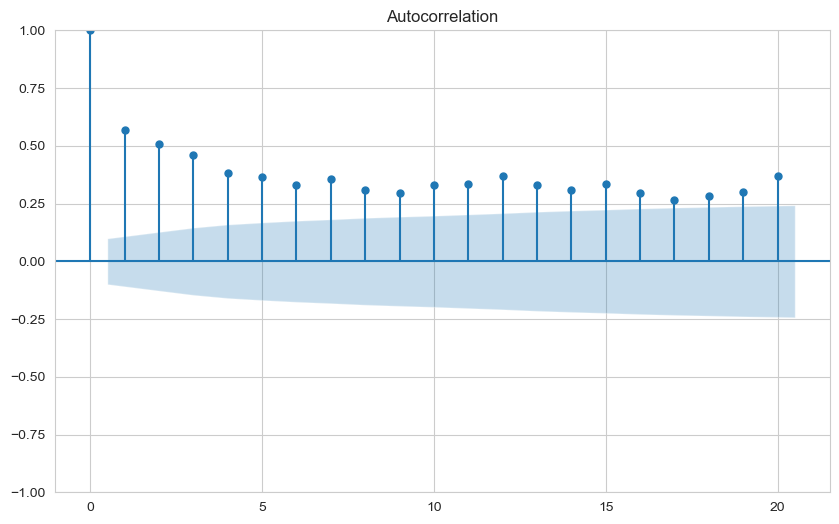

In [42]:
# ACF plot (for time series)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(model.resid, lags = 20)

plt.show()

In [43]:
# Fix - Newey-West robust SE
model_nw = sm.OLS(y, X).fit(cov_type = 'HAC', cov_kwds = {'maxlags':2})
print(model_nw.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     196.8
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.42e-77
Time:                        10:01:06   Log-Likelihood:                -1120.6
No. Observations:                 392   AIC:                             2249.
Df Residuals:                     388   BIC:                             2265.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           44.8559      1.556     28.829   

#### Step 4: Normality of Errors

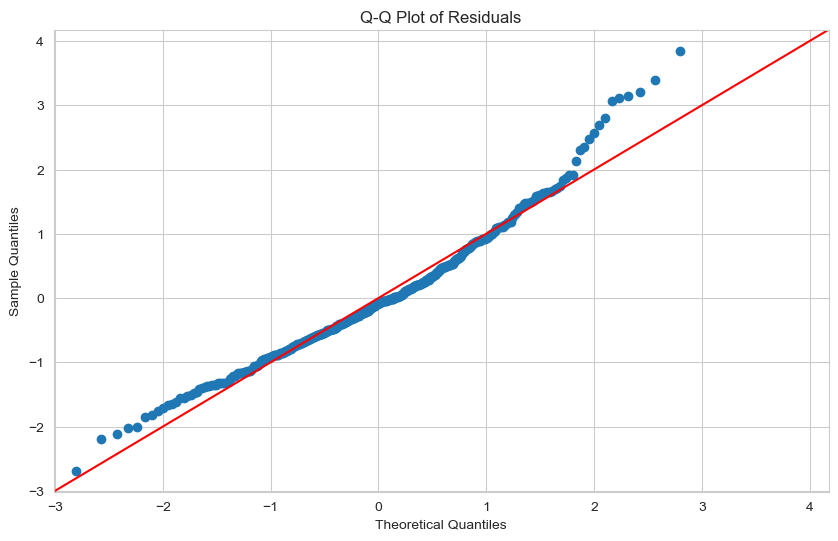

In [44]:
# Visual - Q-Q PLOT
sm.qqplot(model.resid, line = '45', fit = True)
plt.title('Q-Q Plot of Residuals')

plt.show()

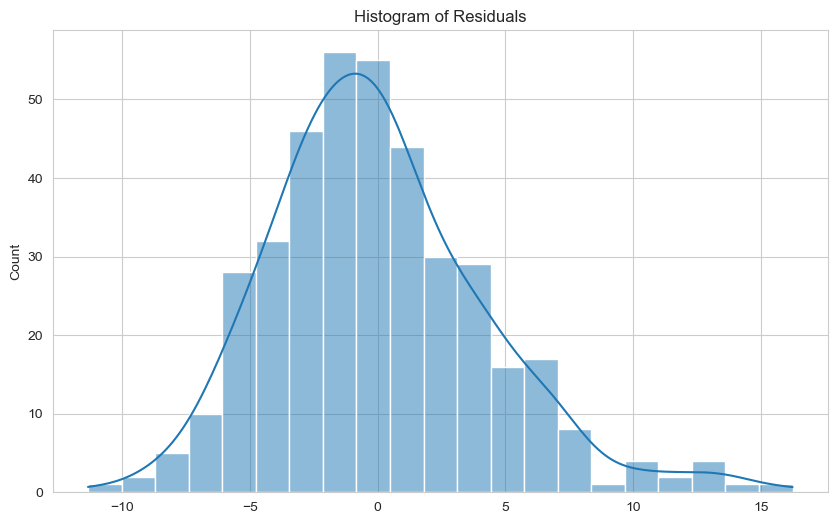

In [46]:
# Histogram
sns.histplot(model.resid, kde = True)
plt.title('Histogram of Residuals')

plt.show()

In [49]:
# Formal Tests
# Shapiro-Wilk (best for small samples)
shapiro_test, shapiro_p = stats.shapiro(model.resid)
print(f'Shapiro-Wilk: stat = {shapiro_test:.4f}, p = {shapiro_p:.4f}')

# Jarque-Bera (good for large samples)
jb_stat, jb_p, skew, kurtosis = sm.stats.jarque_bera(model.resid)
print(f"Jarque-Bera: stat = {jb_stat:.4f}, p={jb_p:.4f}, skew = {skew:.3f}, kurtosis = {kurtosis:.3f}")

Shapiro-Wilk: stat = 0.9718, p = 0.0000
Jarque-Bera: stat = 49.9460, p=0.0000, skew = 0.707, kurtosis = 4.029


In [51]:
# Fixed if violated
y_log = np.log(df['mpg'])
model_log = sm.OLS(y_log, X).fit()
model_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     483.8
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          1.07e-130
Time:                        10:11:06   Log-Likelihood:                 172.15
No. Observations:                 392   AIC:                            -336.3
Df Residuals:                     388   BIC:                            -320.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.0633      0.044     91.922      0.000       3.976       4.150
horsepower      -0.0022      0.000     -4.677      0.000      -0.003      -0.001
weight          -0.0002   2.63e-05     -8.487      0.000      -0.000      -0.000
displacement    -0.0004      0.000     -1.441      0.150      -0.001       0.000
==============================================================================
Omnibus:                        3.298   Durbin-Watson:                   0.872
Prob(Omnibus):                  0.192   Jarque-Bera (JB):                3.031
Skew:                           0.189   Prob(JB):                        0.220
Kurtosis:                       3.206   Cond. No.                     1.73e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.73e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [54]:
# Or use bootstrap for inference
model_boot = sm.OLS(y, X).fit(cov_type='HC3')  # robust SE
model_boot.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     346.8
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          2.08e-109
Time:                        10:11:40   Log-Likelihood:                -1120.6
No. Observations:                 392   AIC:                             2249.
Df Residuals:                     388   BIC:                             2265.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           44.8559      1.259     35.641      0.000      42.389      47.323
horsepower      -0.0417      0.015     -2.802      0.005      -0.071      -0.013
weight          -0.0054      0.001     -8.408      0.000      -0.007      -0.004
displacement    -0.0058      0.007     -0.802      0.423      -0.020       0.008
==============================================================================
Omnibus:                       37.603   Durbin-Watson:                   0.859
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.946
Skew:                           0.707   Prob(JB):                     1.43e-11
Kurtosis:                       4.029   Cond. No.                     1.73e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 1.73e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Step 5: Homoscedasticity

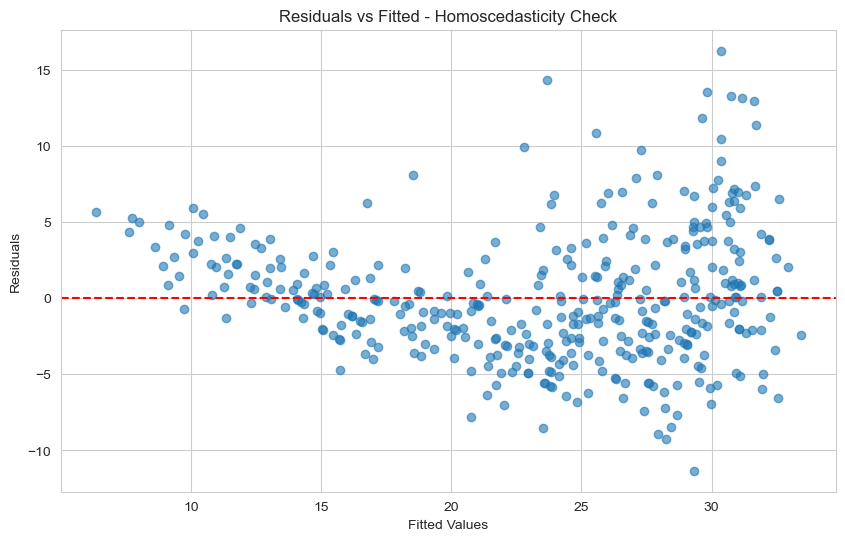

In [55]:
# Visual - Residuals vs Fitted
plt.scatter(fitted, residuals, alpha = 0.6)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted - Homoscedasticity Check')

plt.show()

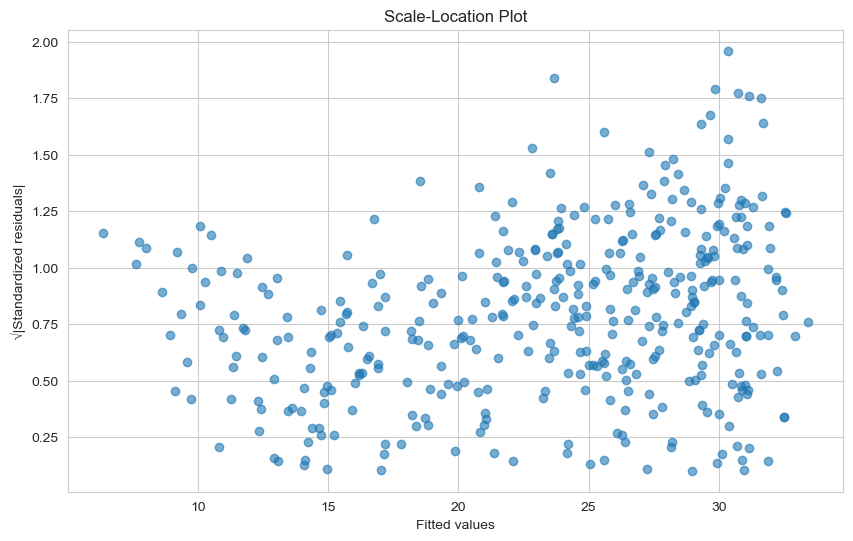

In [56]:
# Scale-Location Plot
standardized_resid = model.resid / model.resid.std()
plt.scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha = 0.6)
plt.xlabel('Fitted values')
plt.ylabel('√|Standardized residuals|')
plt.title('Scale-Location Plot')

plt.show()

In [59]:
# Formal Test
# Breusch-Pagan test
bp_stat, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan: stat={bp_stat:.3f}, p={bp_p:.4f}")

# White test
from statsmodels.stats.diagnostic import het_white
white_stat, white_p, _, _ = het_white(model.resid, model.model.exog)
print(f"White test: stat={white_stat:.3f}, p={white_p:.4f}")

Breusch-Pagan: stat=28.245, p=0.0000
White test: stat=61.885, p=0.0000


In [61]:
# Fix if violated
model_robust = sm.OLS(y, X).fit(cov_type = 'HC3')

print(model_robust.summary())

# Or Weighted Least Squares
# Or log-transform Y

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     346.8
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          2.08e-109
Time:                        10:21:34   Log-Likelihood:                -1120.6
No. Observations:                 392   AIC:                             2249.
Df Residuals:                     388   BIC:                             2265.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           44.8559      1.259     35.641   

#### Step 6: Multicollinearity

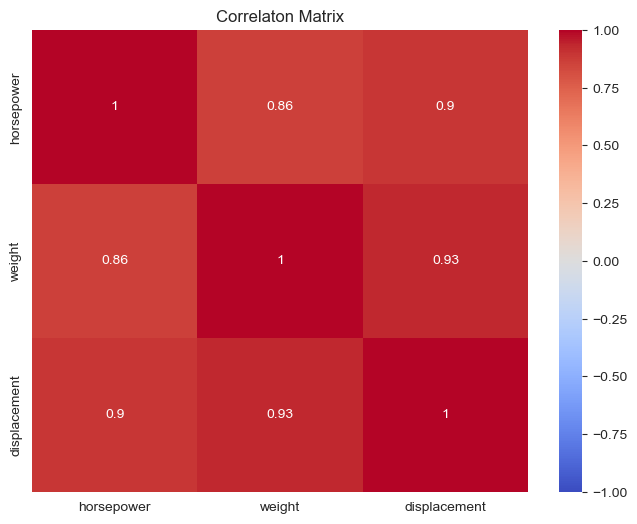

In [62]:
# Correlation Matrix
plt.figure(figsize = (8,6))

sns.heatmap(df[['horsepower', 'weight', 'displacement']].corr(), annot = True, cmap = 'coolwarm', vmin = - 1, vmax = 1)
plt.title('Correlaton Matrix')

plt.show()

In [66]:
# VIF - Variance Inflation Factor
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data

,feature,VIF
0,const,31.164849
1,horsepower,5.287295
2,weight,7.957383
3,displacement,10.310539


In [67]:
# Fix if violated
X_reduced = X.drop(columns = ['displacement'])

# Or use Ridge regression
# from sklearn.linear_model import Ridge
# ridge = Ridge(alpha=1.0).fit(X.drop(columns='const'), y)

# Or PCA
# from sklearn.decomposition import PCA

In [68]:
sm.OLS(y, X_reduced).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     467.9
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          3.06e-104
Time:                        10:30:30   Log-Likelihood:                -1121.0
No. Observations:                 392   AIC:                             2248.
Df Residuals:                     389   BIC:                             2260.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.6402      0.793     57.540      0.000      44.081      47.200
horsepower    -0.0473      0.011     -4.267      0.000      -0.069      -0.026
weight        -0.0058      0.001    -11.535      0.000      -0.007      -0.005
==============================================================================
Omnibus:                       35.336   Durbin-Watson:                   0.858
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.973
Skew:                           0.683   Prob(JB):                     1.04e-10
Kurtosis:                       3.974   Cond. No.                     1.15e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.15e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Step 7: Influential Outliers

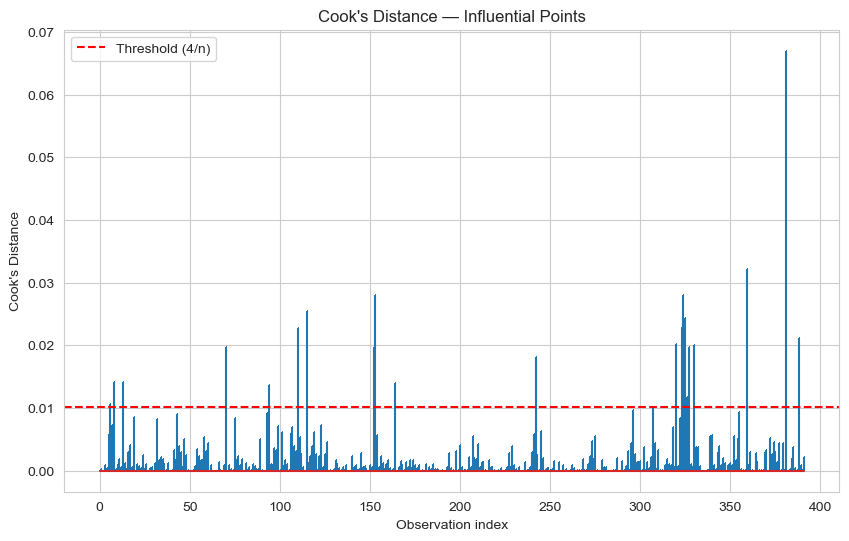

In [70]:
# Cook's Distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(4/len(df), color='red', linestyle='--', label='Threshold (4/n)')
plt.xlabel('Observation index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.title("Cook's Distance — Influential Points")

plt.show()

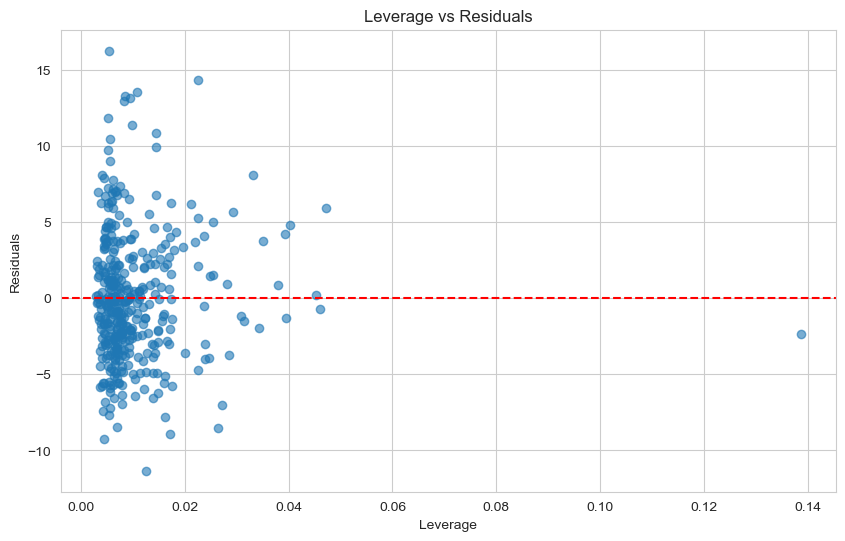

In [71]:
# Leverage - Hat Values
leverage = influence.hat_matrix_diag

plt.scatter(leverage, model.resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Leverage vs Residuals')

plt.show()

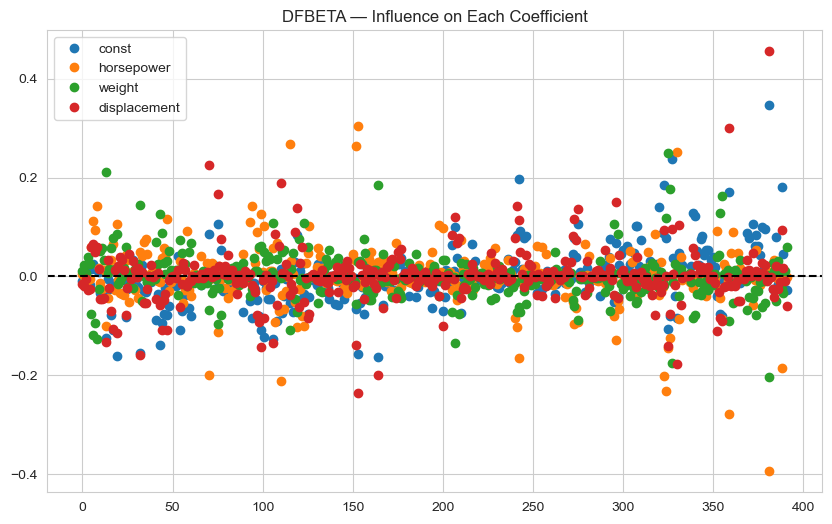

In [72]:
dfbetas = influence.dfbetas
# Plot DFBETA for each coefficient
for i, col in enumerate(X.columns):
    plt.plot(dfbetas[:, i], marker='o', linestyle='', label=col)
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.title('DFBETA — Influence on Each Coefficient')
plt.show()

In [74]:
# # Fix if violated
# # Identify and investigate
# influential_points = np.where(cooks_d > 4/len(df))[0]
# print(df.iloc[influential_points])

# # Compare model with and without
# df_clean = df.drop(index=influential_points)
# model_clean = sm.OLS(df_clean['mpg'], sm.add_constant(df_clean[['horsepower', 'weight', 'displacement']])).fit()

# # Or use robust regression (RLM)
# rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
# print(rlm_model.summary())

#### Step 8: All in one diagnostic plot

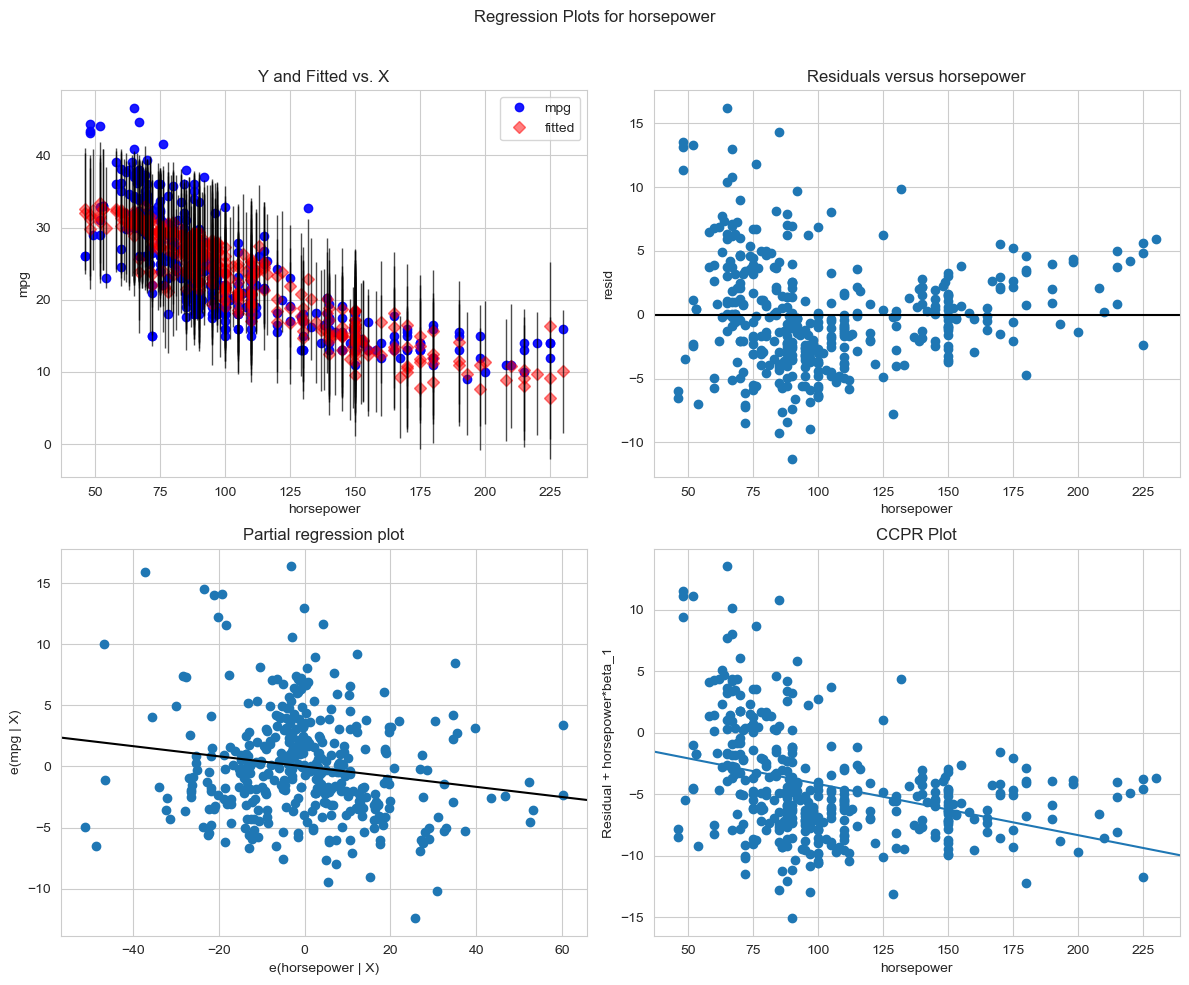

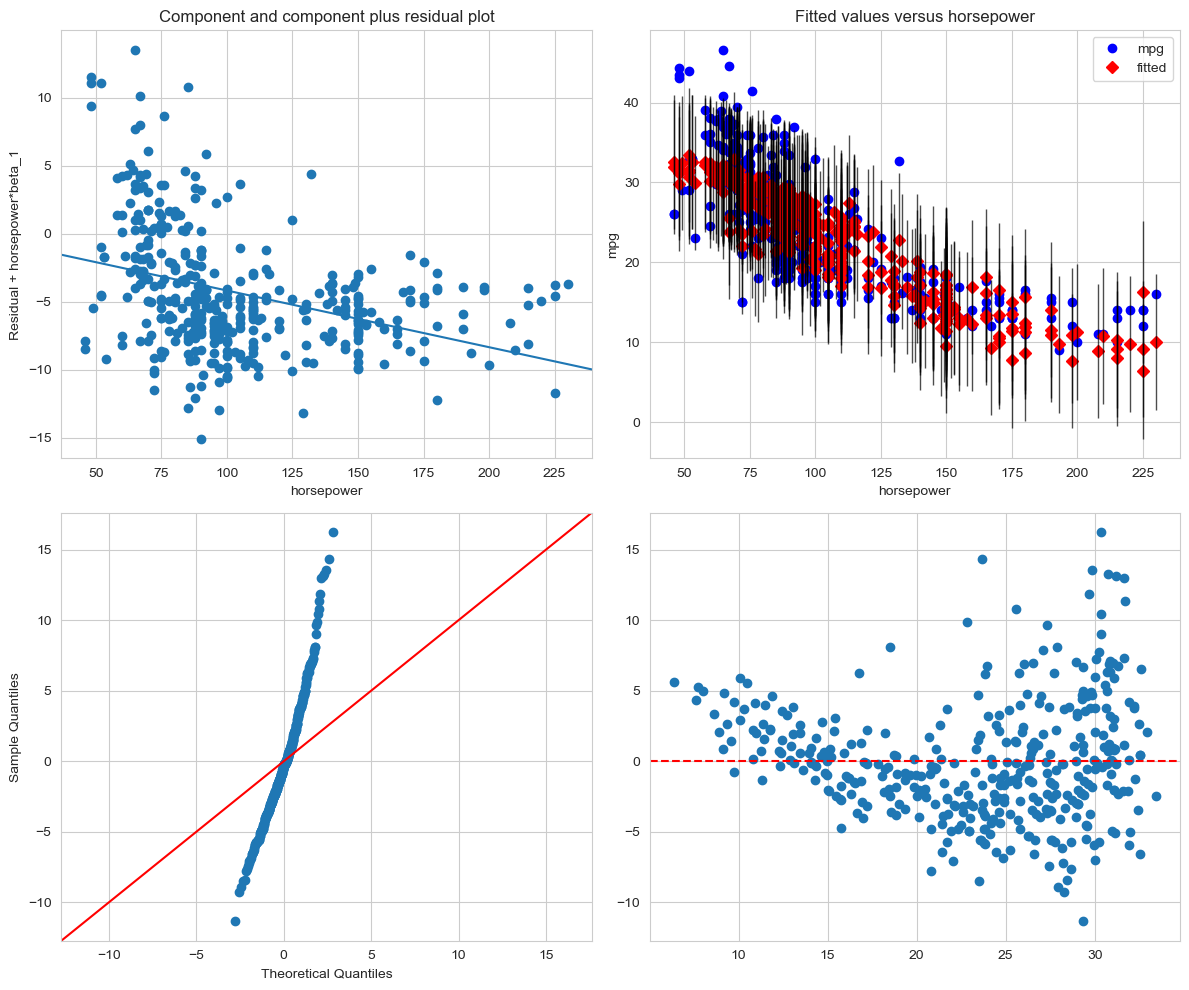

In [75]:
fig = plt.figure(figsize=(12, 10))
sm.graphics.plot_regress_exog(model, 'horsepower', fig=fig)
plt.show()

# Or the classic 4-panel
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sm.graphics.plot_ccpr(model, 'horsepower', ax=axes[0,0])
sm.graphics.plot_fit(model, 'horsepower', ax=axes[0,1])
sm.qqplot(model.resid, line='45', ax=axes[1,0])
axes[1,1].scatter(model.fittedvalues, model.resid)
axes[1,1].axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## Linear Regression Assumption Violations

**Assumption Violated?**

├── **Linearity?** ──────────► Transform X, add polynomials, splines, GAM  
│  
├── **Independence?** ───────► Robust SE (HAC), mixed models, time series models  
│  
├── **Normality?** ──────────► Transform Y, bootstrap, robust regression  
│                              *(less critical if n is large)*  
│  
├── **Homoscedasticity?** ───► Robust SE (HC3), WLS, transform Y  
│  
├── **Multicollinearity?** ──► Drop, combine, PCA, Ridge/Lasso  
│  
└── **Outliers?** ───────────► Investigate, robust regression, winsorize